# Criando a base de dados


In [2]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42) #semente
ages = np.random.randint(low=15, high=70, size=40)

ages

array([53, 66, 43, 29, 57, 22, 35, 53, 33, 37, 25, 25, 38, 67, 50, 54, 38,
       17, 36, 67, 16, 38, 58, 44, 52, 16, 35, 47, 26, 36, 58, 39, 63, 41,
       56, 42, 30, 29, 61, 65], dtype=int32)

In [3]:
label = []
for age in ages:
    if age <30:
        label.append(0)
    else:
        label.append(1)

#random swap
for i in range(0,3):
    r = np.random.randint(0, len(label) - 1)
    if label[r] == 0:
        label[r] = 1
    else:
        label[r] = 0

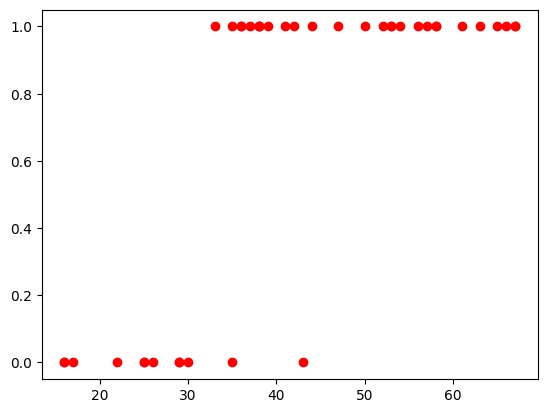

In [4]:
plt.scatter(ages, label, color="red")
plt.show()

# Predição usando Regressão Linear

In [5]:
import numpy as np
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(ages.reshape(-1, 1), label)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [6]:
#y = mx + b
m = model.coef_[0]
b = model.intercept_
print(m)
print(b)

0.02256675230371327
-0.2573944664850354


# Entendendo os Coeficientes da Reta

MovieWriter ffmpeg unavailable; using Pillow instead.


ValueError: unknown file extension: .mp4

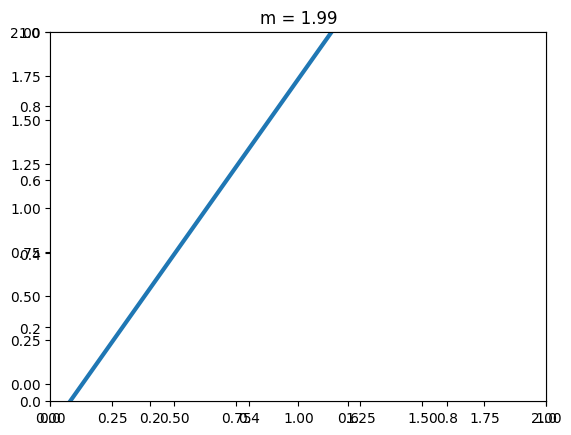

In [7]:
from matplotlib.animation import FuncAnimation

fig, ax = plt.subplots()

# marking the x-axis and y-axis
axis = plt.axes(xlim = (0, 2),
                ylim = (-0.1, 2))

# Initializing Line variable
line, = axis.plot([], [], lw = 3)

# data which the line will contain (x, y)
def init():
    line.set_data([], [])
    return line,
def animate(i):
    m_copy = i * 0.01
    plt.title("m = " + str(m_copy))
    x = np.arange(0.0, 10.0, 0.1)
    y = m_copy * x + b
    line.set_data(x, y)

    return line,

ani = FuncAnimation(fig, animate, init_func=init,
                    frames = 200,
                    interval = 20,
                    blit = True)
# pillow não reconhece mp4, logo, usa-se gif
ani.save("m.mp4",
         writer = "ffmpeg", fps = 30)

In [16]:
from IPython.display import HTML

HTML("""
<div align="midle">
<video width="80%" controls>
    <source src="m.gif" type="video/gif"
    </video></div>""")

# Regressão Linear daquele Conjunto de Pontos

33.56240438551759


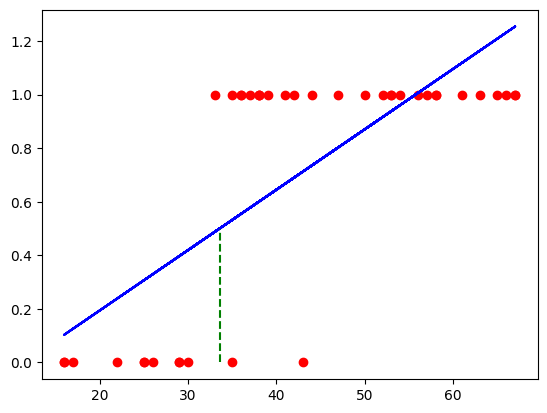

In [18]:
#0.5 = mx + b
#0.5 - b = mx
#(0.5 - b)/m = x
limiar_idade = (0.5 - b)/m
print(limiar_idade)

plt.plot(ages, ages * m + b, color = "blue" )
plt.plot([limiar_idade, limiar_idade], [0, 0.5], "--", color = "green")
plt.scatter(ages, label, color="red")
plt.show()

# Função Logística

y = 1/(1+e**-x)
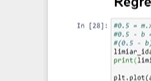

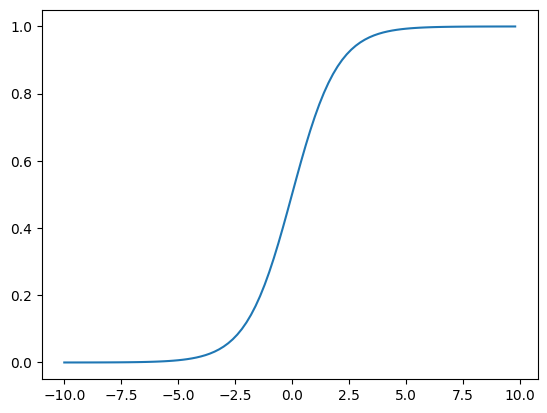

In [9]:
import math

def sigmoid(x):
    a = []
    for item in x:
        a.append(1/(1+math.exp(-item)))
    return a

x = np.arange(-10, 10, 0.2)
sig = sigmoid(x)

plt.plot(x, sig)
plt.show()

# Classificador Sigmóide

33.33144456155554


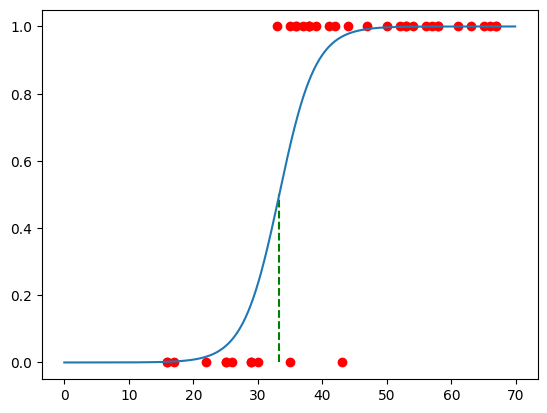

In [10]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression()
model.fit(ages.reshape(-1, 1), label) # Calcula um vetor transposto de linha para coluna

#y = m.x + b
m = model.coef_[0][0]
b = model.intercept_[0]

x = np.arange(0, 70, 0.1)
sig = sigmoid(m*x + b)

limiar_idade = 0 - (b/m)
print(limiar_idade)

plt.scatter(ages, label, color="red")
plt.plot([limiar_idade, limiar_idade], [0, 0.5], "--", color = "green")
plt.plot(x, sig)
plt.show()
